# ALERT AHDC ADC — timeline analysis

Plot the per-wire ADC value vs run number, and flag runs that are abnormal
relative to **adjacent** runs (dead / low / spike).

Input: `alert_adc.csv` with columns `run, layer_number, layer_code, wire, value, graph_name`
(produced by `dump_alert_adc_csv.groovy`).

Run the cells top to bottom. Edit `CSV_PATH` in the first code cell.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "test.csv"   # <-- edit to your file path

# tuning knobs (same defaults as the script)
WINDOW     = 11    # rolling-median window in runs (local baseline)
THRESHOLD  = 5.0   # robust-z threshold for an outlier
DEAD_FRAC  = 0.2   # flag value below this fraction of the wire's median

## 1. Load the CSV (drops any blank/ATOF rows automatically)

In [2]:
def load(path):
    df = pd.read_csv(path)
    for c in ("run", "layer_number", "wire", "value"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
    before = len(df)
    df = df.dropna(subset=["run", "layer_number", "wire", "value"])
    if before - len(df):
        print(f"note: dropped {before - len(df)} blank row(s)")
    for c in ("run", "layer_number", "wire"):
        df[c] = df[c].astype(int)
    df["value"] = df["value"].astype(float)
    return df.sort_values(["layer_number", "wire", "run"]).reset_index(drop=True)

df = load(CSV_PATH)
print(f"{len(df)} rows | {df.layer_number.nunique()} layers | "
      f"{df.groupby(['layer_number','wire']).ngroups} wires | "
      f"runs {df.run.min()}-{df.run.max()}")
df.head()

59998 rows | 2 layers | 57 wires | runs 21317-23061


,run,layer_number,layer_code,wire,value,graph_name
0,21317,1,11,1,0.021524,ahdc_adc_layer1_wire_number01
1,21322,1,11,1,0.025642,ahdc_adc_layer1_wire_number01
2,21323,1,11,1,0.029197,ahdc_adc_layer1_wire_number01
3,21325,1,11,1,0.040096,ahdc_adc_layer1_wire_number01
4,21326,1,11,1,0.036734,ahdc_adc_layer1_wire_number01


## 2. Detection logic (per wire, vs adjacent runs)

In [3]:
def detect_wire(g, window=WINDOW, threshold=THRESHOLD, dead_frac=DEAD_FRAC):
    """Flag anomalous runs for ONE wire's time-ordered series."""
    g = g.sort_values("run").copy()
    v = g["value"].to_numpy(float)
    local_med = (g["value"].rolling(window, center=True, min_periods=3)
                 .median().bfill().ffill())
    detrended = v - local_med.to_numpy()
    mad = np.median(np.abs(detrended - np.median(detrended)))
    scale = 1.4826 * mad if mad > 0 else 0.0
    robust_z = detrended / scale if scale > 0 else np.zeros_like(v)
    wire_med = np.median(v)
    dead_floor = dead_frac * wire_med
    is_outlier = (scale > 0) & (np.abs(robust_z) > threshold)
    is_low = v < dead_floor
    g["local_median"] = local_med.to_numpy()
    g["robust_z"] = robust_z
    g["dead_floor"] = dead_floor
    g["flag"] = is_outlier | is_low
    g["reason"] = np.where(is_low, "low/dead", np.where(is_outlier, "outlier", ""))
    return g

## 3. Plot one wire (inline)\nEdit `LAYER` and `WIRE`.

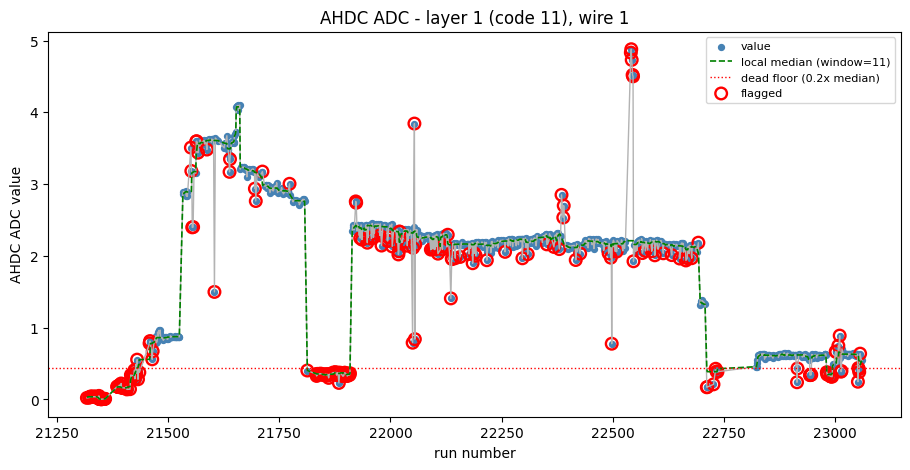

,run,value,local_median,robust_z,reason
0,21317,0.021524,0.032966,-0.514132,low/dead
1,21322,0.025642,0.036724,-0.498006,low/dead
2,21323,0.029197,0.036729,-0.338469,low/dead
3,21325,0.040096,0.036724,0.151507,low/dead
4,21326,0.036734,0.036729,0.000222,low/dead
...,...,...,...,...,...
1059,23052,0.246654,0.613902,-16.503002,low/dead
1060,23053,0.437684,0.613902,-7.918698,outlier
1061,23054,0.421993,0.544524,-5.506189,low/dead
1062,23055,0.382371,0.538513,-7.016522,low/dead


In [4]:
LAYER, WIRE = 1, 1   # <-- choose layer_number (1-8) and wire

def plot_wire(df, layer, wire, window=WINDOW, threshold=THRESHOLD, dead_frac=DEAD_FRAC):
    g = df[(df.layer_number == layer) & (df.wire == wire)]
    if g.empty:
        print(f"No data for layer {layer} wire {wire}"); return None
    g = detect_wire(g, window, threshold, dead_frac)
    code = g.layer_code.iloc[0] if "layer_code" in g else ""
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(g.run, g.value, "-", color="0.7", lw=1)
    ax.scatter(g.run, g.value, s=18, color="steelblue", label="value")
    ax.plot(g.run, g.local_median, "--", color="green", lw=1.2,
            label=f"local median (window={window})")
    ax.axhline(g.dead_floor.iloc[0], color="red", ls=":", lw=1,
               label=f"dead floor ({dead_frac:g}x median)")
    fl = g[g.flag]
    if not fl.empty:
        ax.scatter(fl.run, fl.value, s=70, facecolors="none",
                   edgecolors="red", linewidths=1.7, label="flagged")
    ax.set_xlabel("run number"); ax.set_ylabel("AHDC ADC value")
    ax.set_title(f"AHDC ADC - layer {layer} (code {code}), wire {wire}")
    ax.legend(fontsize=8); plt.show()
    return g

g = plot_wire(df, LAYER, WIRE)
if g is not None:
    display(g[g.flag][["run", "value", "local_median", "robust_z", "reason"]])

## 4. Scan every wire -> flagged runs + per-wire summary

In [5]:
res = pd.concat([detect_wire(g) for _, g in df.groupby(["layer_number", "wire"])],
                ignore_index=True)
flagged = res[res.flag].copy()
print(f"{len(flagged)} flagged (run,wire) entries out of {len(res)}")

global_typical = res.groupby(["layer_number","wire"]).value.median().median()
summary = (res.groupby(["layer_number","wire"])
           .agg(n_runs=("run","size"), n_flagged=("flag","sum"),
                median_value=("value","median")).reset_index())
summary["frac_flagged"] = summary.n_flagged / summary.n_runs
summary["permanently_low"] = summary.median_value < DEAD_FRAC * global_typical

summary.sort_values(["permanently_low","frac_flagged"], ascending=False).head(20)

14080 flagged (run,wire) entries out of 59998


,layer_number,wire,n_runs,n_flagged,median_value,frac_flagged,permanently_low
40,1,41,1076,438,2.001044,0.407063,False
41,1,42,1025,387,2.030840,0.377561,False
47,2,1,1016,350,0.989011,0.344488,False
52,2,6,997,327,1.511195,0.327984,False
51,2,5,996,318,1.440705,0.319277,False
53,2,7,996,310,1.447714,0.311245,False
3,1,4,996,283,1.956705,0.284137,False
4,1,5,996,280,1.963578,0.281124,False
24,1,25,1056,276,2.066687,0.261364,False
55,2,9,1098,286,1.699936,0.260474,False


## 5. Save the flagged runs to CSV

In [6]:
cols = ["run","layer_number","layer_code","wire","value",
        "local_median","robust_z","reason"]
flagged[[c for c in cols if c in flagged.columns]].to_csv("flagged.csv", index=False)
print("wrote flagged.csv")

wrote flagged.csv


## 6. (optional) Plot the most-flagged wires
Quick visual check of the worst offenders from the summary.

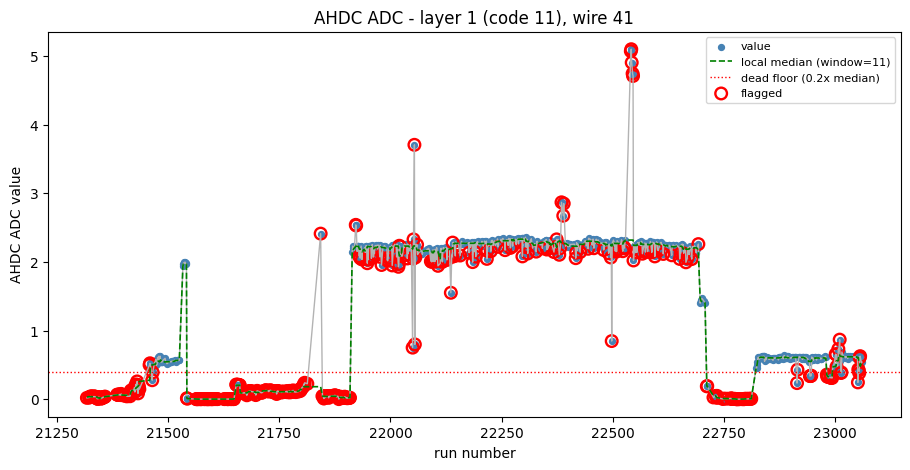

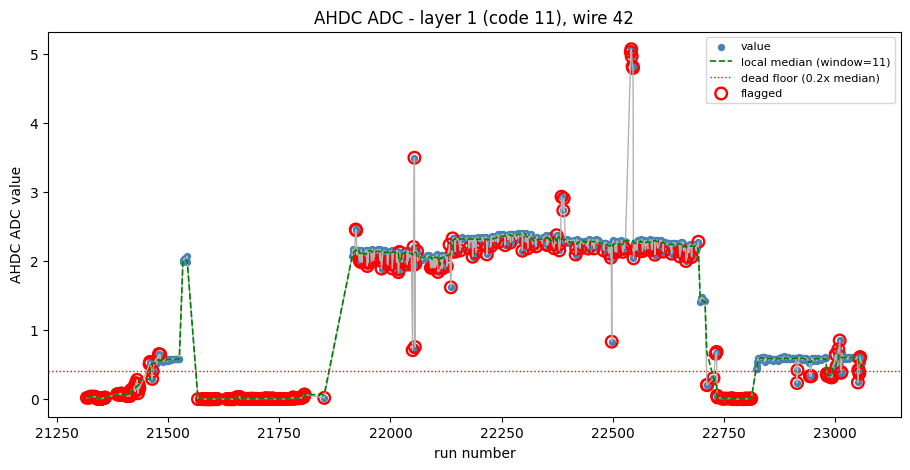

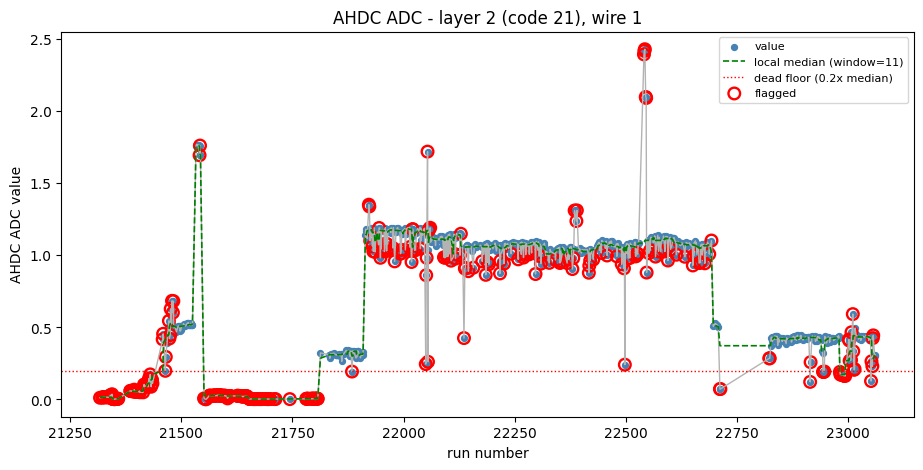

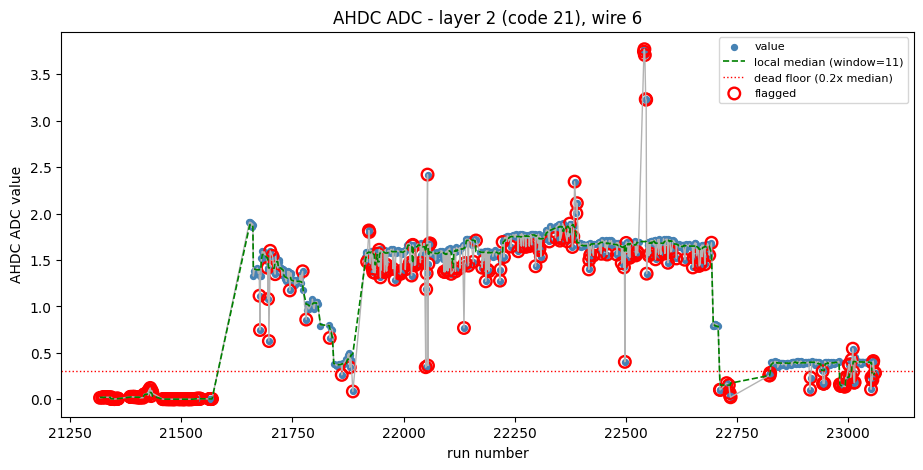

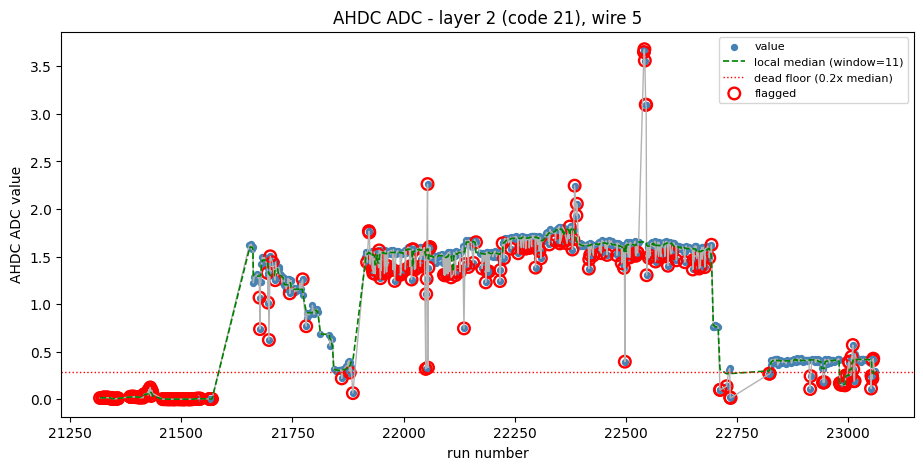

In [7]:
worst = summary.sort_values(["permanently_low","frac_flagged"],
                            ascending=False).head(5)
for _, row in worst.iterrows():
    plot_wire(df, int(row.layer_number), int(row.wire))